<a href="https://colab.research.google.com/github/BG-bibek/BG-bibek/blob/main/week9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Set up Apache Spark in Colab

In [5]:
# ### 1. RDD to DataFrame
# # Need to pass an RDD and a schema (list of column names) into SparkSession's createDataFrame method
# # Create a list of tuples
# sample_list = [('Mona',20), ('Jennifer',34), ('John',20), ('Jim',26)]
# # Create a RDD from the list
# rdd = sc.parallelize(sample_list)
# # Create a PySpark DataFrame
# names_df = spark.createDataFrame(rdd, schema=['Name', 'Age'])
# # Check the type of names_df
# print("The type of names_df is", type(names_df))

In [1]:
# Install pyspark
!pip install pyspark

In [2]:
from pyspark.sql import SparkSession

# Initialize SparkSession
spark = SparkSession.builder.appName("CSVLoad").getOrCreate()

print("SparkSession created successfully!")

SparkSession created successfully!


### Upload your CSV file

To upload your CSV file, use the file upload button in the left sidebar (folder icon) and upload your file (e.g., `my_data.csv`). Make sure to note down the file name you upload.

Once uploaded, you can load it into a Spark DataFrame.

In [9]:
# Replace 'your_file_name.csv' with the actual name of your uploaded CSV file
from google.colab import files

uploaded = files.upload()

# Get the name of the uploaded file(s). Assumes only one file is uploaded.
csv_file_path = list(uploaded.keys())[0]

# Load the CSV file into a Spark DataFrame
# inferSchema allows Spark to automatically detect the schema of the CSV file
# header=True indicates that the first row of the CSV is the header
people_df = spark.read.csv(csv_file_path, header=True, inferSchema=True)

# Display the first 5 rows of the DataFrame and its schema
print("Spark DataFrame created successfully!")
people_df.show(5)
people_df.printSchema()

Saving people.csv to people (2).csv
Spark DataFrame created successfully!
+---+---------+--------------+------+-------------------+
|_c0|person_id|          name|   sex|      date of birth|
+---+---------+--------------+------+-------------------+
|  0|      100|Penelope Lewis|female|1990-08-31 00:00:00|
|  1|      101| David Anthony|  male|1971-10-14 00:00:00|
|  2|      102|     Ida Shipp|female|1962-05-24 00:00:00|
|  3|      103|  Joanna Moore|female|2017-03-10 00:00:00|
|  4|      104|Lisandra Ortiz|female|2020-08-05 00:00:00|
+---+---------+--------------+------+-------------------+
only showing top 5 rows
root
 |-- _c0: integer (nullable = true)
 |-- person_id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- sex: string (nullable = true)
 |-- date of birth: timestamp (nullable = true)



3.2 Operating DataFrames in PySpark
Similar to RDD operations, the DataFrame operations in PySpark (i.e. DataFrame API) can be divided into Transformation and Actions.
DataFrame Transformations:
select() transformation is used to extract one or more columns from a DataFrame and return a new DataFrame.
filter() transformation only select the rows that pass a condition specified.
GroupBy() transformation groups a DataFrame using specified columns, and return a new DataFrame
orderBy() transformation returns a new DataFrame sorted by the given columns.
dropDuplicate() transformation returns a new DataFrame with duplicated rows removed.
withColumnRenamed() transformation returns a new DataFrame by renaming an existing column
DataFrame Actions
printSchema() action prints the types of columns in the DataFrame.
head() action shows the first few rows in the DataFrame.
show() is an action to display the rows in a DataFrame.
count() is an action to show the number of rows in a DataFrame.
columns operator prints the columns of a DataFrame
describe() operation is used to calculate the summary statistics of the numerical columns in the DataFrame.

In [10]:
# Print the first 10 observations
people_df.show(10)
# Count the number of rows
print("There are {} rows in the people_df DataFrame.".format(people_df.count()))
# Count the number of columns and their names
print("There are {} columns in the people_df DataFrame and their names are {}".format(len(people_df.columns), people_df.columns))
# Select name, sex and date of birth columns
people_df_sub = people_df.select('name', 'sex', 'date of birth')
# Print the first 10 observations from people_df_sub
people_df_sub.show(10)
# Remove duplicate entries from people_df_sub
people_df_sub_nodup = people_df_sub.dropDuplicates()
# Count the number of rows
print("There were {} rows before removing duplicates, and {} rows after removing duplicates".format(people_df_sub.count(), people_df_sub_nodup.count()))
# Filter people_df to select females
people_df_female = people_df.filter(people_df.sex == "female")
# Filter people_df to select males
people_df_male = people_df.filter(people_df.sex == "male")
# Count the number of rows
print("There are {} rows in the people_df_female DataFrame and {} rows in the people_df_male DataFrame".format(people_df_female.count(), people_df_male.count()))

+---+---------+----------------+------+-------------------+
|_c0|person_id|            name|   sex|      date of birth|
+---+---------+----------------+------+-------------------+
|  0|      100|  Penelope Lewis|female|1990-08-31 00:00:00|
|  1|      101|   David Anthony|  male|1971-10-14 00:00:00|
|  2|      102|       Ida Shipp|female|1962-05-24 00:00:00|
|  3|      103|    Joanna Moore|female|2017-03-10 00:00:00|
|  4|      104|  Lisandra Ortiz|female|2020-08-05 00:00:00|
|  5|      105|   David Simmons|  male|1999-12-30 00:00:00|
|  6|      106|   Edward Hudson|  male|1983-05-09 00:00:00|
|  7|      107|    Albert Jones|  male|1990-09-13 00:00:00|
|  8|      108|Leonard Cavender|  male|1958-08-08 00:00:00|
|  9|      109|  Everett Vadala|  male|2005-05-24 00:00:00|
+---+---------+----------------+------+-------------------+
only showing top 10 rows
There are 100000 rows in the people_df DataFrame.
There are 5 columns in the people_df DataFrame and their names are ['_c0', 'person_id

3.3 Interacting with DataFrames using PySpark SQL
In addition to the DataFrame API, PySpark SQL allows to manipulate DataFrames with SQL queries programatically. SQL queries can be more concise and easier to understand. It
is portable and can be used without any modifications with every supported languages (e.g. R language).
The SparkSession provides a method called sql which can be used to execute a SQL query. The sql() method takes a SQL statement as an argument and returns a DataFrame
representing the result of the given query. Before issuing a SQL query against a DataFrame, a temporary table needs to be created (using createOrReplaceTempView() function)
which is a pointer to the DataFrame.

In [11]:
# The sql() function on a SparkSession enables applications to run SQL queries programmatically
# and returns the result as another DataFrame
# Create a temporary table "people"
people_df.createOrReplaceTempView("people")
# Construct a query to select the names of the people from the temporary table "people"
query = '''SELECT name FROM people'''
# Assign the result of Spark's query to people_df_names
people_df_names = spark.sql(query)
# Print the top 10 names of the people
people_df_names.show(10)
# Filter the people table to select female sex
people_female_df = spark.sql('SELECT * FROM people WHERE sex=="female"')
# Filter the people table DataFrame to select male sex
people_male_df = spark.sql('SELECT * FROM people WHERE sex=="male"')
# Count the number of rows in both people_df_female and people_male_df DataFrames
print("There are {} rows in the people_female_df and {} rows in the people_male_df DataFrames".format(people_female_df.count(), people_male_df.count()))

+----------------+
|            name|
+----------------+
|  Penelope Lewis|
|   David Anthony|
|       Ida Shipp|
|    Joanna Moore|
|  Lisandra Ortiz|
|   David Simmons|
|   Edward Hudson|
|    Albert Jones|
|Leonard Cavender|
|  Everett Vadala|
+----------------+
only showing top 10 rows
There are 49014 rows in the people_female_df and 49066 rows in the people_male_df DataFrames


##3.4 Data Visualization for PySpark DataFrame
Currently, there are three different methods available to create charts using PySpark DataFrames
pyspark_dist_explore library: Pyspark_dist_explore is a plotting library to get quick insights on data in PySpark DataFrames
toPandas method: converts the PySpark DataFrame into a Pandas DataFrame. After conversion, it's easy to create charts from pandas DataFrames using matplotlib or seaborn
plotting tools.
HandySpark toPandas: HandySpark is designed to improve PySpark user experience, especially when it comes to exploratory data analysis, including visualization capabilities.
Pandas DataFrame vs PySpark DataFrame
Pandas is a single machine tool and constrained by single machine limits. So their size is limited by your server memory, and you will process them with the power of a single
server. In contrast, operations on Pyspark DataFrames run parallel on different nodes in the cluster.
In pandas DataFrames, we get the result as soon as we apply any operation Whereas operations in PySpark DataFrames are lazy in nature.
You can change a Pandas DataFrame using methods. We can’t change a PySpark DataFrame due to its immutable property.
Finally, the Pandas API supports more operations than PySpark DataFrames.

Saving Fifa2018_dataset(1).csv to Fifa2018_dataset(1).csv
root
 |-- _c0: integer (nullable = true)
 |-- Name: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Photo: string (nullable = true)
 |-- Nationality: string (nullable = true)
 |-- Flag: string (nullable = true)
 |-- Overall: integer (nullable = true)
 |-- Potential: integer (nullable = true)
 |-- Club: string (nullable = true)
 |-- Club Logo: string (nullable = true)
 |-- Value: string (nullable = true)
 |-- Wage: string (nullable = true)
 |-- Special: integer (nullable = true)
 |-- Acceleration: string (nullable = true)
 |-- Aggression: string (nullable = true)
 |-- Agility: string (nullable = true)
 |-- Balance: string (nullable = true)
 |-- Ball control: string (nullable = true)
 |-- Composure: string (nullable = true)
 |-- Crossing: string (nullable = true)
 |-- Curve: string (nullable = true)
 |-- Dribbling: string (nullable = true)
 |-- Finishing: string (nullable = true)
 |-- Free kick accuracy: string (

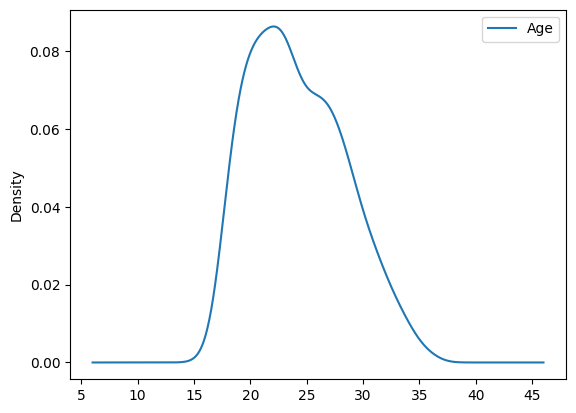

In [13]:
# This exercise will do exploratory data analysis (EDA) on the "FIFA 2018 World Cup Player" dataset using PySpark SQL which involve DataFrame operations, SQL queries
#and visualization.

uploaded = files.upload()

# Get the name of the uploaded file(s). Assumes only one file is uploaded.
csv_file_path = list(uploaded.keys())[0]

# Make you have uploaded the dataset file onto Databricks data store. The file_path is for my Databricks account only. Yours will be different.

#file_path = 'dbfs:/FileStore/shared_uploads/wei.jie@uwl.ac.uk/Fifa2018_dataset.csv'
# Load the Dataframe
fifa_df = spark.read.csv(csv_file_path, header=True, inferSchema=True)
# Check the schema of columns
fifa_df.printSchema()
# Show the first 10 observations
fifa_df.show(10)
# Print the total number of rows
print("There are {} rows in the fifa_df DataFrame".format(fifa_df.count()))
# Create a temporary view of fifa_df
fifa_df.createOrReplaceTempView('fifa_df_table')
# Construct the "query"
query = '''SELECT Age FROM fifa_df_table WHERE Nationality == "Germany"'''
# Apply the SQL "query"
fifa_df_germany_age = spark.sql(query)
# Generate basic statistics
fifa_df_germany_age.describe().show()
# Convert fifa_df to fifa_df_germany_age_pandas DataFrame
fifa_df_germany_age_pandas = fifa_df_germany_age.toPandas()
import matplotlib.pyplot as plt
# Plot the 'Age' density of Germany Players
fifa_df_germany_age_pandas.plot(kind='density')
plt.show()